# Chapter 1: Pappos's Theorem: Nine Proofs and Three Variations

**Source span.** Perspectives on Projective Geometry, Chapter 1, Sections 1.1-1.7, printed pages 3-32 / PDF pages 25-54.

**Chapter goal.** Build a computational picture of why one incidence theorem can survive projective completion, algebraic proof translations, conic deformation, and a circle-geometry variation.

Pappos's theorem starts with two triples of points on two lines. The crossed joins meet in three new points, and the assertion is that those three new points are collinear. The chapter uses that one configuration as an overture: first as an incidence theorem, then as a Euclidean parallel theorem, then as an area identity, then as determinant algebra, then as a degenerate case of Pascal and Cayley-Bacharach-Chasles, and finally as a bridge to Miquel's theorem through complex cross-ratios.

This notebook is not a scan or paraphrase of the source. It rebuilds the chapter's mechanisms as inspectable objects: points are homogeneous vectors, joins and meets are cross products, parallel lines are ordinary projective intersections at infinity, conics are quadratic equations, and cocircularity is tested by the imaginary part of a cross-ratio.


In [1]:
from pathlib import Path
import sys

START = Path.cwd().resolve()
BOOK_ROOT = None
for candidate in [START, *START.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "Perspectives on Projective Geometry.pdf").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not discover the Perspectives on Projective Geometry course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

CHAPTER_SLUG = "chapter-01-pappos-theorem-nine-proofs-and-three-variations"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / CHAPTER_SLUG
for child in ("figures", "html", "tables", "checks"):
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = "printed pages 3-32 / PDF pages 25-54; Sections 1.1-1.7"
ARTIFACT_ROOT.relative_to(BOOK_ROOT)


WindowsPath('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations')

## Computational Translation Guide

| Source idea | Computational object | Invariant checked here |
| --- | --- | --- |
| point in the projective plane | nonzero homogeneous vector `(x, y, z)` up to scale | finite points divide by `z`; points at infinity have `z = 0` |
| line through two points | cross product `p x q` | incident points have dot product zero with the line vector |
| intersection of two lines | cross product `g x h` | the result lies on both input lines |
| three points collinear | determinant/bracket of their homogeneous vectors | determinant is zero after normalization tolerance |
| Euclidean parallelism | projective intersection on the line at infinity | limiting intersection has `z = 0` |
| oriented area proof | signed triangle/quadrangle area polynomials | vanishing areas force the final parallelism |
| conic and circle variants | homogeneous quadratic forms and complex circular points | conic residuals and cross-ratio imaginary parts vanish |

Library choices follow the chapter geometry. Matplotlib is used for durable 2D incidence, area, conic, and proof diagrams; Plotly writes a standalone HTML parameter lab for Miquel deformation; SymPy verifies an exact determinant identity; NumPy carries homogeneous joins/meets; the course artifact helpers record inspection targets. No computer-vision image warping or mesh stack is needed because this chapter is planar projective incidence rather than camera or surface geometry.


In [2]:
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from matplotlib import MatplotlibDeprecationWarning
from IPython.display import Markdown, display
from matplotlib.patches import Polygon

from utils.artifacts import assert_artifacts, book_relative, display_artifact, image_stats, save_json, save_table
from utils.conics import circle_conic, evaluate_conic
from utils.projective import affine, bracket, cross_ratio, hpoint, incidence, join, meet

warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 9,
})

artifact_paths = []
observation_rows = []
visual_checks = {
    "chapter": 1,
    "source_span": SOURCE_SPAN,
}

def rel(path):
    return book_relative(path)

def add_artifact(path, concept, inspect, invariant, library):
    artifact_paths.append(Path(path))
    observation_rows.append({
        "artifact": rel(path),
        "concept": concept,
        "inspect": inspect,
        "invariant": invariant,
        "library": library,
    })

def safe_norm(value):
    value = np.asarray(value, dtype=float)
    return float(np.linalg.norm(value))

def normalized_incidence_residual(point, line):
    denom = max(safe_norm(point) * safe_norm(line), 1e-15)
    return abs(float(np.dot(point, line))) / denom

def collinearity_residual(p, q, r):
    line = join(p, q)
    return normalized_incidence_residual(r, line)

def xy(point):
    return np.asarray(affine(point), dtype=float)


In [3]:
def line_segment(line, xlim, ylim, tol=1e-10):
    a, b, c = np.asarray(line, dtype=float)
    candidates = []
    for x in xlim:
        if abs(b) > tol:
            y = -(a * x + c) / b
            if ylim[0] - tol <= y <= ylim[1] + tol:
                candidates.append((float(x), float(y)))
    for y in ylim:
        if abs(a) > tol:
            x = -(b * y + c) / a
            if xlim[0] - tol <= x <= xlim[1] + tol:
                candidates.append((float(x), float(y)))
    unique = []
    for item in candidates:
        if not any(np.linalg.norm(np.asarray(item) - np.asarray(old)) < 1e-8 for old in unique):
            unique.append(item)
    if len(unique) < 2:
        return None
    best_pair = None
    best_dist = -1.0
    for i in range(len(unique)):
        for j in range(i + 1, len(unique)):
            dist = np.linalg.norm(np.asarray(unique[i]) - np.asarray(unique[j]))
            if dist > best_dist:
                best_dist = dist
                best_pair = (unique[i], unique[j])
    return best_pair

def plot_line(ax, line, xlim, ylim, **kwargs):
    segment = line_segment(line, xlim, ylim)
    if segment is None:
        return None
    p, q = segment
    return ax.plot([p[0], q[0]], [p[1], q[1]], **kwargs)

def label_point(ax, point, label, offset=(0.04, 0.04), **kwargs):
    px, py = map(float, xy(point))
    ax.scatter([px], [py], s=42, zorder=5, **kwargs)
    ax.text(px + offset[0], py + offset[1], label, weight="bold", fontsize=9)

def circle_curve(center, radius, samples=360):
    theta = np.linspace(0, 2 * np.pi, samples)
    return center[0] + radius * np.cos(theta), center[1] + radius * np.sin(theta)

def circle_from_three_points(P, Q, R):
    P, Q, R = map(lambda v: np.asarray(v, dtype=float), (P, Q, R))
    matrix = np.array([
        [2 * (Q[0] - P[0]), 2 * (Q[1] - P[1])],
        [2 * (R[0] - P[0]), 2 * (R[1] - P[1])],
    ])
    rhs = np.array([
        Q[0] ** 2 + Q[1] ** 2 - P[0] ** 2 - P[1] ** 2,
        R[0] ** 2 + R[1] ** 2 - P[0] ** 2 - P[1] ** 2,
    ])
    center = np.linalg.solve(matrix, rhs)
    return center, float(np.linalg.norm(P - center))

def tri_area(P, Q, R):
    matrix = np.array([[P[0], Q[0], R[0]], [P[1], Q[1], R[1]], [1.0, 1.0, 1.0]])
    return 0.5 * float(np.linalg.det(matrix))

def quad_area(P, Q, R, S):
    return tri_area(P, Q, S) + tri_area(Q, R, S)


## Planner Pass: Visual Storyboard

The planner pass treats each visual as a proof instrument, not as a route-map placeholder.

| Order | Concept | Representation | Artifact | What to inspect |
| ---: | --- | --- | --- | --- |
| 1 | Pappos nine-point incidence | homogeneous joins/meets over a labeled diagram | `pappos-nine-point-incidence.png` | the three white intersection points lie on one computed line |
| 2 | projective completion | near-parallel line family and homogeneous limit | `projective-completion-parallel-limit.png` | finite intersections escape but converge to a point with `z = 0` |
| 3 | area proof | oriented triangle/quadrangle tiles | `area-cancellation-tiles.png` | four zero signed areas force the fifth signed area to vanish |
| 4 | determinant proof | cross-product construction and exact SymPy determinant | `determinant-cross-product-proof.png` | a join/meet construction ends with `det(E,F,I) = 0` |
| 5 | Pascal as conic variation | smooth conic beside degenerate two-line case | `pascal-conic-degeneration.png` | the Pascal line persists when Pappos is viewed as a degenerate conic |
| 6 | Cayley-Bacharach-Chasles proof move | cubic factored as conic times residual line | `chasles-residual-line-cubic.png` | six conic zeros leave the remaining zeros on a line |
| 7 | Miquel and cross-ratio lab | circle configuration plus Plotly slider | `miquel-cross-ratio-circles.png`, `miquel-cross-ratio-lab.html` | the cross-ratios are real, so the final four points are cocircular |


In [4]:
storyboard = {
    "chapter goal": "Use Pappos's theorem as a computational gateway to projective completion, determinant proofs, conic variations, and Miquel's circle theorem.",
    "source span read": SOURCE_SPAN,
    "concept inventory": [
        "Pappos nine-point/nine-line incidence configuration",
        "Euclidean parallel specialization and line at infinity",
        "segment-ratio proof limitations and oriented-area replacement",
        "homogeneous coordinates, joins, meets, and determinant collinearity",
        "Grassmann-Plucker style determinant cancellation",
        "Pascal theorem as a conic generalization of Pappos",
        "Cayley-Bacharach-Chasles residual line principle for cubics",
        "circular points I,J, Miquel theorem, and complex cross-ratio cancellations",
    ],
    "library routing table": [
        {"concept": "incidence diagrams", "representation": "labeled 2D projective construction", "library": "Matplotlib + NumPy", "why": "joins, meets, and determinant residuals are visible and durable as PNG", "fallback": "static SVG"},
        {"concept": "exact determinant identity", "representation": "symbolic cross-product construction", "library": "SymPy", "why": "the determinant proof is algebraic and exact", "fallback": "numeric determinant samples"},
        {"concept": "Miquel deformation", "representation": "interactive circle family", "library": "Plotly HTML", "why": "the learner can vary the side circles while watching the residual stay real", "fallback": "saved static PNG plus CSV residuals"},
        {"concept": "inspection/check records", "representation": "CSV and JSON", "library": "course artifact helpers", "why": "final validation can detect stale or blank artifacts", "fallback": "plain JSON"},
    ],
    "visual sequence": [
        {"artifact_filename": "pappos-nine-point-incidence.png", "validation": "dot products and conclusion-line residual"},
        {"artifact_filename": "projective-completion-parallel-limit.png", "validation": "intersection tends to a point incident with the line at infinity"},
        {"artifact_filename": "area-cancellation-tiles.png", "validation": "oriented area identity residual"},
        {"artifact_filename": "determinant-cross-product-proof.png", "validation": "exact symbolic determinant is zero"},
        {"artifact_filename": "pascal-conic-degeneration.png", "validation": "Pascal collinearity residual"},
        {"artifact_filename": "chasles-residual-line-cubic.png", "validation": "conic and residual line equations vanish at marked points"},
        {"artifact_filename": "miquel-cross-ratio-circles.png", "validation": "cross-ratio imaginary residual"},
        {"artifact_filename": "miquel-cross-ratio-lab.html", "validation": "frame residual table"},
    ],
    "artifact plan": {
        "root": f"artifacts/{CHAPTER_SLUG}",
        "figures": [
            "pappos-nine-point-incidence.png",
            "projective-completion-parallel-limit.png",
            "area-cancellation-tiles.png",
            "determinant-cross-product-proof.png",
            "pascal-conic-degeneration.png",
            "chasles-residual-line-cubic.png",
            "miquel-cross-ratio-circles.png",
        ],
        "html": ["miquel-cross-ratio-lab.html"],
        "tables": ["pappos-observation-targets.csv"],
        "checks": ["storyboard.json", "visual-checks.json", "final-sanity.json"],
    },
    "proof-visualization strategy": "Use area cancellation, determinant cross-products, conic deformation, and cross-ratio cancellation as separate proof-state views.",
    "acceptance criteria": [
        "nbclient executes the canonical notebook",
        "artifact paths are book-local and concept-named",
        "final sanity JSON asserts incidence, area, determinant, conic, and cross-ratio residuals",
        "generic route-map scaffold is absent",
    ],
}
save_json(storyboard, ARTIFACT_ROOT, "checks", "storyboard.json")
storyboard["artifact plan"]


{'root': 'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations',
 'figures': ['pappos-nine-point-incidence.png',
  'projective-completion-parallel-limit.png',
  'area-cancellation-tiles.png',
  'determinant-cross-product-proof.png',
  'pascal-conic-degeneration.png',
  'chasles-residual-line-cubic.png',
  'miquel-cross-ratio-circles.png'],
 'html': ['miquel-cross-ratio-lab.html'],
 'tables': ['pappos-observation-targets.csv'],
 'checks': ['storyboard.json', 'visual-checks.json', 'final-sanity.json']}

## 1. Pappos Configuration as Data

The diagram below is computed from six starting points on two lines. Each crossed line is a homogeneous join. Each white point is a homogeneous meet. The conclusion line is not drawn by eye; it is the join of the first two intersection points, and the third point is checked against it.

The point of this representation is that the same code handles finite and limiting configurations. A near miss in a picture is not accepted as incidence unless the dot product or determinant residual is small.


In [5]:
A, B, C = hpoint(-2.4, 1.1), hpoint(-0.5, 1.1), hpoint(1.6, 1.1)
X, Y, Z = hpoint(-1.6, -1.0), hpoint(0.2, -1.0), hpoint(2.2, -1.0)

line_top = join(A, C)
line_bottom = join(X, Z)
zigzags = {
    "AY": join(A, Y),
    "BX": join(B, X),
    "BZ": join(B, Z),
    "CY": join(C, Y),
    "CX": join(C, X),
    "AZ": join(A, Z),
}
P = meet(zigzags["AY"], zigzags["BX"])
Q = meet(zigzags["BZ"], zigzags["CY"])
R = meet(zigzags["CX"], zigzags["AZ"])
conclusion_line = join(P, Q)

pappos_residual = collinearity_residual(P, Q, R)
incidence_residuals = {
    "P on AY": normalized_incidence_residual(P, zigzags["AY"]),
    "P on BX": normalized_incidence_residual(P, zigzags["BX"]),
    "Q on BZ": normalized_incidence_residual(Q, zigzags["BZ"]),
    "Q on CY": normalized_incidence_residual(Q, zigzags["CY"]),
    "R on CX": normalized_incidence_residual(R, zigzags["CX"]),
    "R on AZ": normalized_incidence_residual(R, zigzags["AZ"]),
}

fig, ax = plt.subplots(figsize=(8.4, 4.8))
xlim, ylim = (-2.9, 2.7), (-1.55, 1.55)
for line, color, width, label in [
    (line_top, "#264653", 2.3, "input line a"),
    (line_bottom, "#264653", 2.3, "input line b"),
    (conclusion_line, "#c1121f", 2.6, "Pappos conclusion line"),
]:
    plot_line(ax, line, xlim, ylim, color=color, lw=width, label=label)
for name, line in zigzags.items():
    plot_line(ax, line, xlim, ylim, color="#6c757d", lw=1.2, alpha=0.72)
for name, point in {"A": A, "B": B, "C": C, "X": X, "Y": Y, "Z": Z}.items():
    label_point(ax, point, name, color="#1d3557")
for name, point in {"P": P, "Q": Q, "R": R}.items():
    label_point(ax, point, name, color="white", edgecolor="#c1121f", linewidth=1.5)
ax.text(-2.72, 1.38, "six starting points", color="#264653", fontsize=9)
ax.text(-2.72, -1.42, "crossed joins meet in P, Q, R", color="#6c757d", fontsize=9)
ax.text(0.55, 0.22, f"collinearity residual {pappos_residual:.1e}", color="#c1121f", fontsize=9)
ax.set_title("Pappos configuration: joins, meets, and the forced conclusion line")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
ax.legend(loc="upper right", frameon=False)

pappos_path = ARTIFACT_ROOT / "figures" / "pappos-nine-point-incidence.png"
fig.savefig(pappos_path)
plt.close(fig)

visual_checks["pappos_collinearity_residual"] = float(pappos_residual)
visual_checks["pappos_incidence_residuals"] = {k: float(v) for k, v in incidence_residuals.items()}
add_artifact(
    pappos_path,
    "Pappos nine-point incidence configuration",
    "Track the six crossed joins and verify that P, Q, and R sit on the red line.",
    "All six meet incidences and the P,Q,R collinearity residual vanish within tolerance.",
    "NumPy homogeneous joins/meets + Matplotlib",
)
rel(pappos_path), pappos_residual


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pappos-nine-point-incidence.png',
 1.3297573369024505e-17)

## 2. Projective Completion Removes the Parallel Exception

In Euclidean language, parallel lines are exceptional because they have no finite intersection. Projectively, the same family has a limiting intersection on the line at infinity. The next figure makes that transition explicit: the finite intersection of `y = 0` and `y = m x + 1` moves farther away as `m` approaches zero, while the homogeneous vector tends toward a point with third coordinate zero.


In [6]:
slopes = np.array([-0.80, -0.35, -0.16, -0.07, 0.07, 0.16, 0.35, 0.80])
horizontal = np.array([0.0, 1.0, 0.0])
limit_point = np.array([1.0, 0.0, 0.0])
completion_rows = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.4, 4.4), gridspec_kw={"width_ratios": [1.45, 1.0]})
x = np.linspace(-8, 8, 250)
ax1.axhline(0, color="#1d3557", lw=2.4, label="fixed line y=0")
colors = plt.cm.coolwarm(np.linspace(0.08, 0.92, len(slopes)))
for m, color in zip(slopes, colors):
    line = np.array([-m, 1.0, -1.0])
    point = meet(horizontal, line)
    finite_x = point[0] / point[2]
    completion_rows.append({"slope": float(m), "intersection_x": float(finite_x), "homogeneous": [float(v) for v in point]})
    ax1.plot(x, m * x + 1, color=color, lw=1.5, alpha=0.88)
    if -8 <= finite_x <= 8:
        ax1.scatter([finite_x], [0], color=color, s=28, zorder=4)
    sample_x = 5.05 if finite_x > 0 else -7.75
    ax1.text(sample_x, m * sample_x + 1, f"m={m:+.2f}", color=color, fontsize=8)
ax1.annotate("intersections escape\nas m -> 0", xy=(7.2, 0.0), xytext=(3.0, -1.6), arrowprops={"arrowstyle": "->", "color": "#c1121f"}, color="#c1121f")
ax1.set_title("Euclidean view: finite intersections run away")
ax1.set_xlim(-8, 8)
ax1.set_ylim(-3.2, 3.2)
ax1.set_aspect("equal", adjustable="box")
ax1.grid(alpha=0.18)

abs_slope = np.abs(slopes)
intersection_distance = np.abs([row["intersection_x"] for row in completion_rows])
ax2.loglog(abs_slope, intersection_distance, "o-", color="#2a9d8f", lw=2)
ax2.set_xlabel("|slope m|")
ax2.set_ylabel("|finite x-intersection|")
ax2.set_title("Projective view: one limiting direction")
ax2.grid(alpha=0.25, which="both")
ax2.text(0.08, 18.0, "limit point [1, 0, 0]\nlies on z = 0", fontsize=9, color="#264653")

completion_path = ARTIFACT_ROOT / "figures" / "projective-completion-parallel-limit.png"
fig.savefig(completion_path)
plt.close(fig)

line_at_infinity = np.array([0.0, 0.0, 1.0])
completion_limit_residual = abs(float(np.dot(limit_point, line_at_infinity)))
visual_checks["projective_completion"] = {
    "limit_point": [1.0, 0.0, 0.0],
    "line_at_infinity_incidence_residual": completion_limit_residual,
    "max_distance_times_slope_error": float(max(abs(abs(row["intersection_x"]) * abs(row["slope"]) - 1.0) for row in completion_rows)),
}
add_artifact(
    completion_path,
    "Projective completion of parallel lines",
    "Follow the finite intersections as the slope approaches zero and compare with the homogeneous limit.",
    "The limiting point has z=0 and is incident with the line at infinity.",
    "NumPy homogeneous meet + Matplotlib",
)
rel(completion_path), visual_checks["projective_completion"]


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/projective-completion-parallel-limit.png',
 {'limit_point': [1.0, 0.0, 0.0],
  'line_at_infinity_incidence_residual': 0.0,
  'max_distance_times_slope_error': 0.0})

## 3. Area-Cancellation Proof View

The segment-ratio proof is quick, but it depends on an auxiliary intersection point and on sign cases. The area method replaces ratios with signed polynomials. The key identity is that a surrounding quadrangle area equals the signed sum of two triangle tiles and two quadrangle tiles. When the Pappos parallel hypotheses make four of those terms vanish, the remaining quadrangle area must vanish, which is exactly the final parallelism.


In [7]:
A2 = np.array([0.0, 1.0])
B2 = np.array([1.0, 1.0])
C2 = np.array([2.0, 1.0])
Y2 = np.array([0.2, 0.0])
X2 = np.array([1.2, 0.0])
Z2 = np.array([-0.8, 0.0])
area_terms = {
    "area(A,C,B)": tri_area(A2, C2, B2),
    "area(X,Y,Z)": tri_area(X2, Y2, Z2),
    "area(B,Y,X,A)": quad_area(B2, Y2, X2, A2),
    "area(C,Z,Y,B)": quad_area(C2, Z2, Y2, B2),
    "-area(C,Z,X,A)": -quad_area(C2, Z2, X2, A2),
}
area_identity_residual = abs(sum(area_terms.values()))
final_parallel_area = quad_area(C2, Z2, X2, A2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.2, 4.4), gridspec_kw={"width_ratios": [1.25, 1.0]})
polygons = [
    ("triangle ACB", [A2, C2, B2], "#8ecae6"),
    ("triangle XYZ", [X2, Y2, Z2], "#ffb703"),
    ("quad BYXA", [B2, Y2, X2, A2], "#90be6d"),
    ("quad CZYB", [C2, Z2, Y2, B2], "#f4a261"),
    ("outer CZXA", [C2, Z2, X2, A2], "none"),
]
for name, vertices, color in polygons:
    patch = Polygon(vertices, closed=True, facecolor=color, edgecolor="#333333", alpha=0.30 if color != "none" else 1.0, lw=1.6 if color == "none" else 1.0, linestyle="--" if color == "none" else "-")
    ax1.add_patch(patch)
for label, point in {"A": A2, "B": B2, "C": C2, "X": X2, "Y": Y2, "Z": Z2}.items():
    ax1.scatter(point[0], point[1], color="#1d3557", s=38, zorder=4)
    ax1.text(point[0] + 0.035, point[1] + 0.045, label, weight="bold")
for P0, P1 in [(A2, Y2), (B2, X2), (B2, Z2), (C2, Y2), (A2, Z2), (C2, X2)]:
    ax1.plot([P0[0], P1[0]], [P0[1], P1[1]], color="#6c757d", lw=1.1, alpha=0.75)
ax1.text(-0.72, 0.48, "zero signed quadrangles\nencode parallelism", color="#c1121f", fontsize=9)
ax1.set_title("Area proof specialization")
ax1.set_xlim(-1.05, 2.25)
ax1.set_ylim(-0.32, 1.32)
ax1.set_aspect("equal", adjustable="box")
ax1.axis("off")

names = list(area_terms.keys())
values = [area_terms[name] for name in names]
ax2.barh(range(len(values)), values, color=["#8ecae6", "#ffb703", "#90be6d", "#f4a261", "#c1121f"])
ax2.axvline(0, color="#333333", lw=1)
ax2.set_yticks(range(len(values)), labels=names)
ax2.set_title("Signed-area terms")
ax2.set_xlabel("oriented area")
for index, value in enumerate(values):
    ax2.text(value + (0.03 if value >= 0 else -0.03), index, f"{value:.1e}", va="center", ha="left" if value >= 0 else "right", fontsize=8)
ax2.text(0.02, 4.55, f"identity residual {area_identity_residual:.1e}", color="#264653", fontsize=9)

area_path = ARTIFACT_ROOT / "figures" / "area-cancellation-tiles.png"
fig.savefig(area_path)
plt.close(fig)

visual_checks["area_identity_residual"] = float(area_identity_residual)
visual_checks["area_final_parallel_residual"] = float(abs(final_parallel_area))
visual_checks["area_terms"] = {name: float(value) for name, value in area_terms.items()}
add_artifact(
    area_path,
    "Oriented-area cancellation proof",
    "Compare the tile picture with the signed-area bar chart; zero quadrangle area means parallel opposite sides.",
    "The area identity residual and the final quadrangle area vanish.",
    "NumPy determinant areas + Matplotlib",
)
rel(area_path), area_terms


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/area-cancellation-tiles.png',
 {'area(A,C,B)': 0.0,
  'area(X,Y,Z)': 0.0,
  'area(B,Y,X,A)': 0.0,
  'area(C,Z,Y,B)': 1.1102230246251565e-16,
  '-area(C,Z,X,A)': -2.220446049250313e-16})

## 4. Determinant and Cross-Product Proof View

The homogeneous-coordinate proof turns incidence into linear algebra. A join and a meet are both cross products. Three points are collinear exactly when the determinant of their representative vectors is zero. The symbolic check below uses a normalized version of the chapter's final construction sequence; it proves that the determinant vanishes identically, not merely in one drawing.


In [8]:
# Exact symbolic construction with three normalized anchor points.
u1, u2, u3, v1, v2, v3 = sp.symbols("u1 u2 u3 v1 v2 v3")
SA = sp.Matrix([1, 0, 0])
SB = sp.Matrix([0, 1, 0])
SC = sp.Matrix([0, 0, 1])
SD = sp.Matrix([u1, u2, u3])
SE = sp.Matrix([v1, v2, v3])

def scross(p, q):
    return sp.Matrix([
        p[1] * q[2] - p[2] * q[1],
        p[2] * q[0] - p[0] * q[2],
        p[0] * q[1] - p[1] * q[0],
    ])

SF = scross(scross(SA, SD), scross(SB, SC))
SG = scross(scross(SA, SB), scross(SD, SE))
SH = scross(scross(SC, SD), scross(SB, SE))
SI = scross(scross(SA, SH), scross(SC, SG))
symbolic_det = sp.factor(sp.Matrix.hstack(SE, SF, SI).det())
assert symbolic_det == 0

# A finite numeric instance for the visual proof state.
NA = hpoint(1.9945121442679201, 1.0174038844139899)
NB = hpoint(0.33660672437748396, 0.48035855953130513)
NC = hpoint(-0.17372377468804379, 0.09087255362077684)
ND = hpoint(-1.0657799575313307, 0.42537516925729735)
NE = hpoint(0.20822346171118156, -1.085394798864852)
NF = meet(join(NA, ND), join(NB, NC))
NG = meet(join(NA, NB), join(ND, NE))
NH = meet(join(NC, ND), join(NB, NE))
NI = meet(join(NA, NH), join(NC, NG))
numeric_det_residual = collinearity_residual(NE, NF, NI)

fig, (ax, panel) = plt.subplots(1, 2, figsize=(10.6, 4.8), gridspec_kw={"width_ratios": [1.35, 1.0]})
xlim, ylim = (-1.35, 2.25), (-1.30, 1.30)
construction_lines = [
    (join(NA, ND), "AD"), (join(NB, NC), "BC"),
    (join(NA, NB), "AB"), (join(ND, NE), "DE"),
    (join(NC, ND), "CD"), (join(NB, NE), "BE"),
    (join(NA, NH), "AH"), (join(NC, NG), "CG"),
]
for line, name in construction_lines:
    plot_line(ax, line, xlim, ylim, color="#8d99ae", lw=1.0, alpha=0.62)
plot_line(ax, join(NE, NF), xlim, ylim, color="#c1121f", lw=2.4, label="det(E,F,I)=0 line")
for label, point in {"A": NA, "B": NB, "C": NC, "D": ND, "E": NE}.items():
    label_point(ax, point, label, color="#1d3557")
for label, point in {"F": NF, "G": NG, "H": NH, "I": NI}.items():
    label_point(ax, point, label, color="white", edgecolor="#c1121f", linewidth=1.3)
ax.set_title("Cross-product construction sequence")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
ax.legend(frameon=False, loc="lower right")

panel.axis("off")
panel.set_title("Exact determinant scaffold")
formula_lines = [
    "F = (A x D) x (B x C)",
    "G = (A x B) x (D x E)",
    "H = (C x D) x (B x E)",
    "I = (A x H) x (C x G)",
    "",
    "collinearity test:",
    "det(E, F, I) = 0",
    "",
    f"numeric residual {numeric_det_residual:.1e}",
    "SymPy factor result: 0",
]
for i, text in enumerate(formula_lines):
    panel.text(0.02, 0.93 - i * 0.083, text, family="monospace", fontsize=9, color="#222222" if i != 6 else "#c1121f")

cross_path = ARTIFACT_ROOT / "figures" / "determinant-cross-product-proof.png"
fig.savefig(cross_path)
plt.close(fig)

visual_checks["determinant_cross_product"] = {
    "symbolic_det_zero": bool(symbolic_det == 0),
    "numeric_collinearity_residual": float(numeric_det_residual),
}
add_artifact(
    cross_path,
    "Determinant cross-product proof",
    "Read the construction as a sequence of joins and meets; the red line is certified by det(E,F,I)=0.",
    "The exact symbolic determinant factors to zero and the numeric residual vanishes.",
    "SymPy exact algebra + NumPy homogeneous geometry + Matplotlib",
)
rel(cross_path), symbolic_det


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/determinant-cross-product-proof.png',
 0)

## 5. Conic Variants: Pascal and the Degenerate Pappos Case

A pair of lines is a degenerate conic. Pascal's theorem says that the Pappos conclusion line still appears when the six starting points lie on a genuine conic. The left panel computes Pascal's line for six points on an ellipse; the right panel reminds us that Pappos is the two-line limiting case of the same determinant pattern.


In [9]:
rx, ry = 1.7, 1.0
angles = [3.076229951019868, 0.8860164842576905, 0.07431012196783993, -1.373878656724424, -1.9724536197111833, -2.3117479561090097]
labels = ["A", "B", "C", "X", "Y", "Z"]
ellipse_points = {label: hpoint(rx * math.cos(theta), ry * math.sin(theta)) for label, theta in zip(labels, angles)}
EA, EB, EC, EX, EY, EZ = [ellipse_points[label] for label in labels]
EP = meet(join(EA, EY), join(EB, EX))
EQ = meet(join(EB, EZ), join(EC, EY))
ER = meet(join(EC, EX), join(EA, EZ))
pascal_line = join(EP, EQ)
pascal_residual = collinearity_residual(EP, EQ, ER)

theta = np.linspace(0, 2 * np.pi, 420)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.8))
ax1.plot(rx * np.cos(theta), ry * np.sin(theta), color="#2a9d8f", lw=2.2, label="conic")
for name, point in ellipse_points.items():
    label_point(ax1, point, name, color="#1d3557")
for line in [join(EA, EY), join(EB, EX), join(EB, EZ), join(EC, EY), join(EC, EX), join(EA, EZ)]:
    plot_line(ax1, line, (-3.2, 3.2), (-2.4, 1.6), color="#8d99ae", lw=1.0, alpha=0.65)
plot_line(ax1, pascal_line, (-3.2, 3.2), (-2.4, 1.6), color="#c1121f", lw=2.3, label="Pascal line")
for name, point in {"P": EP, "Q": EQ, "R": ER}.items():
    label_point(ax1, point, name, color="white", edgecolor="#c1121f", linewidth=1.3)
ax1.set_title(f"Pascal on a smooth conic; residual {pascal_residual:.1e}")
ax1.set_xlim(-3.2, 3.2)
ax1.set_ylim(-2.4, 1.6)
ax1.set_aspect("equal", adjustable="box")
ax1.axis("off")
ax1.legend(frameon=False, loc="upper right")

for line, color, width in [(line_top, "#264653", 2.2), (line_bottom, "#264653", 2.2), (conclusion_line, "#c1121f", 2.5)]:
    plot_line(ax2, line, (-2.9, 2.7), (-1.55, 1.55), color=color, lw=width)
for line in zigzags.values():
    plot_line(ax2, line, (-2.9, 2.7), (-1.55, 1.55), color="#8d99ae", lw=1.0, alpha=0.55)
for name, point in {"A": A, "B": B, "C": C, "X": X, "Y": Y, "Z": Z}.items():
    label_point(ax2, point, name, color="#1d3557")
for name, point in {"P": P, "Q": Q, "R": R}.items():
    label_point(ax2, point, name, color="white", edgecolor="#c1121f", linewidth=1.3)
ax2.text(-2.62, 1.38, "degenerate conic = two lines", color="#264653", fontsize=9)
ax2.set_title("Pappos as Pascal's two-line limit")
ax2.set_xlim(-2.9, 2.7)
ax2.set_ylim(-1.55, 1.55)
ax2.set_aspect("equal", adjustable="box")
ax2.axis("off")

pascal_path = ARTIFACT_ROOT / "figures" / "pascal-conic-degeneration.png"
fig.savefig(pascal_path)
plt.close(fig)

visual_checks["pascal_collinearity_residual"] = float(pascal_residual)
add_artifact(
    pascal_path,
    "Pascal conic variation and Pappos degeneration",
    "Compare the red conclusion line on an ellipse with the same conclusion line in the two-line degeneration.",
    "The three Pascal intersection points are collinear within determinant tolerance.",
    "NumPy homogeneous joins/meets + Matplotlib",
)
rel(pascal_path), pascal_residual


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pascal-conic-degeneration.png',
 5.982734399821528e-17)

## 6. Cayley-Bacharach-Chasles as a Residual-Line Scaffold

The chapter's second conic variation invokes a stronger algebraic-geometry move: two cubics meet in nine points, and if six of those points lie on a conic, the other three must lie on a line. The proof idea is visible in a factored cubic. Once a cubic member of the pencil contains the conic as a factor, what remains is a linear factor, so the residual zeros are collinear.

The next artifact does not try to render the full theorem as a black box. It isolates the proof step: a cubic `p(x,y,z) = C(x,y,z) L(x,y,z)` has the conic `C = 0` and the residual line `L = 0` as its two visible components.


In [10]:
xx = np.linspace(-2.4, 2.4, 420)
yy = np.linspace(-1.8, 1.8, 360)
XX, YY = np.meshgrid(xx, yy)
conic_value = (XX / 1.45) ** 2 + (YY / 0.92) ** 2 - 1.0
line_value = 0.58 * XX - YY - 0.18
cubic_value = conic_value * line_value

six_angles = np.linspace(0.15, 2 * np.pi - 0.55, 6)
six_conic_points = [np.array([1.45 * np.cos(t), 0.92 * np.sin(t)]) for t in six_angles]
residual_x = np.array([-1.55, -0.15, 1.35])
residual_points = [np.array([x0, 0.58 * x0 - 0.18]) for x0 in residual_x]
conic_residual = max(abs((p[0] / 1.45) ** 2 + (p[1] / 0.92) ** 2 - 1.0) for p in six_conic_points)
line_residual = max(abs(0.58 * p[0] - p[1] - 0.18) for p in residual_points)

fig, ax = plt.subplots(figsize=(7.4, 5.0))
ax.contour(XX, YY, cubic_value, levels=[0], colors=["#333333"], linewidths=1.0, alpha=0.35)
ax.contour(XX, YY, conic_value, levels=[0], colors=["#2a9d8f"], linewidths=2.4)
ax.contour(XX, YY, line_value, levels=[0], colors=["#c1121f"], linewidths=2.4)
for i, point in enumerate(six_conic_points, start=1):
    ax.scatter(point[0], point[1], color="#2a9d8f", s=42, zorder=4)
    ax.text(point[0] + 0.04, point[1] + 0.04, str(i), weight="bold", color="#145a4a")
for i, point in enumerate(residual_points, start=7):
    ax.scatter(point[0], point[1], color="white", edgecolor="#c1121f", linewidth=1.5, s=52, zorder=5)
    ax.text(point[0] + 0.04, point[1] + 0.04, str(i), weight="bold", color="#c1121f")
ax.text(-2.22, 1.45, "factored cubic: C(x,y,z) * L(x,y,z)", fontsize=10, color="#333333")
ax.text(-2.22, 1.22, "six zeros on the conic", color="#2a9d8f", fontsize=9)
ax.text(-2.22, 1.03, "three residual zeros on a line", color="#c1121f", fontsize=9)
ax.set_title("Cayley-Bacharach-Chasles proof move: conic factor leaves a residual line")
ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-1.8, 1.8)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.16)

chasles_path = ARTIFACT_ROOT / "figures" / "chasles-residual-line-cubic.png"
fig.savefig(chasles_path)
plt.close(fig)

visual_checks["chasles_residual_line"] = {
    "max_conic_residual_at_six_points": float(conic_residual),
    "max_line_residual_at_three_points": float(line_residual),
}
add_artifact(
    chasles_path,
    "Cayley-Bacharach-Chasles residual line scaffold",
    "Identify the conic component and the residual line component of a factored cubic.",
    "The six marked conic points satisfy C=0 and the three residual points satisfy L=0.",
    "NumPy polynomial sampling + Matplotlib contouring",
)
rel(chasles_path), visual_checks["chasles_residual_line"]


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/chasles-residual-line-cubic.png',
 {'max_conic_residual_at_six_points': 1.1102230246251565e-16,
  'max_line_residual_at_three_points': 5.551115123125783e-17})

## 7. Miquel's Theorem and Cross-Ratio Cancellations

The circle variation uses a different completion: lines can be treated as circles through one added point, and ordinary circles can be characterized projectively by the two complex circular points at infinity. In the finite complex plane, four points are cocircular exactly when a certain cross-ratio is real.

The construction below starts with four cyclic points `A,B,C,D`, draws a circle through each adjacent pair, and computes the other four intersections `E,F,G,H`. The cross-ratio product is the lab version of the cancellation proof: each assumed circle gives a real cross-ratio, so the final cross-ratio for `E,F,G,H` is real as well.


In [11]:
BASE_A = np.array([-0.8, -0.6])
BASE_B = np.array([-0.8, 0.6])
BASE_C = np.array([0.8, 0.6])
BASE_D = np.array([0.8, -0.6])
BASE_POINTS = [BASE_A, BASE_B, BASE_C, BASE_D]
BASE_BULGES = np.array([0.4, 0.5, 0.6, 0.7])

def side_circle(P, Q, bulge):
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    midpoint = 0.5 * (P + Q)
    direction = Q - P
    length = np.linalg.norm(direction)
    perpendicular = np.array([-direction[1], direction[0]]) / length
    center = midpoint + bulge * perpendicular
    radius = float(np.linalg.norm(P - center))
    return center, radius

def circle_intersections(c0, r0, c1, r1):
    c0, c1 = np.asarray(c0, dtype=float), np.asarray(c1, dtype=float)
    delta = c1 - c0
    d = float(np.linalg.norm(delta))
    a = (r0 * r0 - r1 * r1 + d * d) / (2 * d)
    h_sq = max(r0 * r0 - a * a, 0.0)
    h = math.sqrt(h_sq)
    base = c0 + a * delta / d
    perpendicular = np.array([-delta[1], delta[0]]) / d
    return [base + h * perpendicular, base - h * perpendicular]

def other_intersection(intersections, shared_point):
    return max(intersections, key=lambda point: np.linalg.norm(point - shared_point))

def miquel_configuration(scale=1.0):
    bulges = BASE_BULGES * scale
    circles = [
        side_circle(BASE_A, BASE_B, bulges[0]),
        side_circle(BASE_B, BASE_C, bulges[1]),
        side_circle(BASE_C, BASE_D, bulges[2]),
        side_circle(BASE_D, BASE_A, bulges[3]),
    ]
    Fp = other_intersection(circle_intersections(*circles[0], *circles[1]), BASE_B)
    Gp = other_intersection(circle_intersections(*circles[1], *circles[2]), BASE_C)
    Hp = other_intersection(circle_intersections(*circles[2], *circles[3]), BASE_D)
    Ep = other_intersection(circle_intersections(*circles[3], *circles[0]), BASE_A)
    final_center, final_radius = circle_from_three_points(Ep, Fp, Gp)
    return {"circles": circles, "E": Ep, "F": Fp, "G": Gp, "H": Hp, "final_circle": (final_center, final_radius), "scale": scale}

def zpoint(point):
    return complex(float(point[0]), float(point[1]))

def miquel_cross_ratio_report(config):
    A0, B0, C0, D0 = map(zpoint, BASE_POINTS)
    E0, F0, G0, H0 = [zpoint(config[key]) for key in ("E", "F", "G", "H")]
    ratios = {
        "ABCD": ((A0 - B0) * (C0 - D0)) / ((C0 - B0) * (A0 - D0)),
        "ABEF": ((F0 - B0) * (A0 - E0)) / ((A0 - B0) * (F0 - E0)),
        "BCFG": ((C0 - B0) * (F0 - G0)) / ((F0 - B0) * (C0 - G0)),
        "CDGH": ((H0 - D0) * (C0 - G0)) / ((C0 - D0) * (H0 - G0)),
        "DAHE": ((A0 - D0) * (H0 - E0)) / ((H0 - D0) * (A0 - E0)),
    }
    product = np.prod(list(ratios.values()))
    conclusion = ((F0 - G0) * (H0 - E0)) / ((H0 - G0) * (F0 - E0))
    imag_error = max([abs(value.imag) for value in ratios.values()] + [abs(conclusion.imag), abs((product - conclusion).imag), abs(product - conclusion)])
    return ratios, product, conclusion, float(imag_error)


In [12]:
miquel = miquel_configuration(1.0)
ratios, product_ratio, conclusion_ratio, miquel_error = miquel_cross_ratio_report(miquel)

fig, ax = plt.subplots(figsize=(7.0, 6.0))
base_center, base_radius = circle_from_three_points(BASE_A, BASE_B, BASE_C)
for center, radius, color, label in [(base_center, base_radius, "#264653", "base circle")]:
    cx, cy = circle_curve(center, radius)
    ax.plot(cx, cy, color=color, lw=2.2, linestyle="--", label=label)
for index, (center, radius) in enumerate(miquel["circles"], start=1):
    cx, cy = circle_curve(center, radius)
    ax.plot(cx, cy, color=plt.cm.viridis(0.15 + 0.16 * index), lw=1.6, alpha=0.86)
final_center, final_radius = miquel["final_circle"]
cx, cy = circle_curve(final_center, final_radius)
ax.plot(cx, cy, color="#c1121f", lw=2.4, label="circle through E,F,G,H")
for label, point in {"A": BASE_A, "B": BASE_B, "C": BASE_C, "D": BASE_D}.items():
    ax.scatter(point[0], point[1], color="#1d3557", s=48, zorder=5)
    ax.text(point[0] + 0.035, point[1] + 0.035, label, weight="bold")
for label, point in {"E": miquel["E"], "F": miquel["F"], "G": miquel["G"], "H": miquel["H"]}.items():
    ax.scatter(point[0], point[1], color="white", edgecolor="#c1121f", linewidth=1.4, s=58, zorder=6)
    ax.text(point[0] + 0.035, point[1] + 0.035, label, color="#c1121f", weight="bold")
ax.text(-1.48, -1.22, f"max cross-ratio residual {miquel_error:.1e}\nconclusion ratio = {conclusion_ratio.real:.6f} + {conclusion_ratio.imag:.1e}i", fontsize=9, color="#333333")
ax.set_title("Miquel configuration: cross-ratio reality certifies the final circle")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.58, 1.58)
ax.set_ylim(-1.38, 1.42)
ax.axis("off")
ax.legend(frameon=False, loc="upper right")

miquel_path = ARTIFACT_ROOT / "figures" / "miquel-cross-ratio-circles.png"
fig.savefig(miquel_path)
plt.close(fig)

# Circular points check for ordinary circles represented as conics.
I = np.array([1.0 + 0.0j, 1.0j, 0.0 + 0.0j])
J = np.array([1.0 + 0.0j, -1.0j, 0.0 + 0.0j])
circle_checks = []
for center, radius in [(np.array([0.0, 0.0]), 1.0), (np.array([0.35, -0.2]), 1.4), (np.array([-0.4, 0.55]), 0.9)]:
    conic = circle_conic(float(center[0]), float(center[1]), float(radius)).astype(complex)
    circle_checks.append(max(abs(I @ conic @ I), abs(J @ conic @ J)))
circular_point_residual = float(max(circle_checks))

visual_checks["miquel_cross_ratio"] = {
    "side_ratio_imag_max": float(max(abs(value.imag) for value in ratios.values())),
    "product_minus_conclusion_abs": float(abs(product_ratio - conclusion_ratio)),
    "conclusion_imag_abs": float(abs(conclusion_ratio.imag)),
    "max_cross_ratio_residual": float(miquel_error),
    "circular_point_residual": circular_point_residual,
}
visual_checks["cross_ratio_error"] = float(miquel_error)
add_artifact(
    miquel_path,
    "Miquel theorem and cross-ratio cancellation",
    "Inspect the four side circles, the second intersections E,F,G,H, and the final red circle.",
    "All required cross-ratios are real and their product equals the final cocircularity cross-ratio.",
    "NumPy circle intersections + complex cross-ratios + Matplotlib",
)
rel(miquel_path), conclusion_ratio, miquel_error


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/miquel-cross-ratio-circles.png',
 (-2.1884631750319126+5.508262605419392e-15j),
 2.279947064476391e-13)

### Interactive Miquel Lab

Move the slider in the saved HTML artifact. The side circles change shape, but the final cross-ratio residual remains near machine precision. That is the computational version of the chapter's cancellation proof: deformation changes the drawing, not the invariant.


In [13]:
def miquel_plotly_traces(scale):
    config = miquel_configuration(scale)
    traces = []
    base_center, base_radius = circle_from_three_points(BASE_A, BASE_B, BASE_C)
    bx, by = circle_curve(base_center, base_radius, samples=220)
    traces.append(go.Scatter(x=bx, y=by, mode="lines", name="base circle", line={"color": "#264653", "dash": "dash", "width": 2}))
    colors = ["#2a9d8f", "#457b9d", "#f4a261", "#6a4c93"]
    for index, (center, radius) in enumerate(config["circles"]):
        cx, cy = circle_curve(center, radius, samples=220)
        traces.append(go.Scatter(x=cx, y=cy, mode="lines", name=f"side circle {index+1}", line={"color": colors[index], "width": 2}))
    fc, fr = config["final_circle"]
    fx, fy = circle_curve(fc, fr, samples=220)
    traces.append(go.Scatter(x=fx, y=fy, mode="lines", name="E,F,G,H circle", line={"color": "#c1121f", "width": 3}))
    all_labels = ["A", "B", "C", "D", "E", "F", "G", "H"]
    all_points = BASE_POINTS + [config[key] for key in ("E", "F", "G", "H")]
    traces.append(go.Scatter(
        x=[float(point[0]) for point in all_points],
        y=[float(point[1]) for point in all_points],
        text=all_labels,
        mode="markers+text",
        textposition="top center",
        marker={"size": 9, "color": ["#1d3557"] * 4 + ["#ffffff"] * 4, "line": {"color": ["#1d3557"] * 4 + ["#c1121f"] * 4, "width": 2}},
        name="points",
    ))
    return traces

scales = [0.65, 0.82, 1.00, 1.18, 1.35]
frame_checks = []
for scale in scales:
    config = miquel_configuration(scale)
    _, product, conclusion, error = miquel_cross_ratio_report(config)
    frame_checks.append({"scale": scale, "cross_ratio_error": error, "conclusion_real": float(conclusion.real), "product_minus_conclusion_abs": float(abs(product - conclusion))})

fig = go.Figure(data=miquel_plotly_traces(scales[0]))
fig.frames = [go.Frame(data=miquel_plotly_traces(scale), name=f"{scale:.2f}") for scale in scales]
fig.update_layout(
    title=f"Miquel cross-ratio lab: scale {scales[0]:.2f}",
    width=820,
    height=620,
    xaxis={"range": [-1.75, 1.75], "scaleanchor": "y", "zeroline": False},
    yaxis={"range": [-1.55, 1.55], "zeroline": False},
    margin={"l": 30, "r": 30, "t": 70, "b": 30},
    sliders=[{
        "steps": [
            {"method": "animate", "label": f"{scale:.2f}", "args": [[f"{scale:.2f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
            for scale in scales
        ],
        "active": 0,
        "currentvalue": {"prefix": "side-circle scale: "},
    }],
    updatemenus=[{"type": "buttons", "showactive": False, "buttons": [{"label": "play", "method": "animate", "args": [None, {"frame": {"duration": 650, "redraw": True}, "fromcurrent": True}]}, {"label": "stop", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}]}],
)

lab_path = ARTIFACT_ROOT / "html" / "miquel-cross-ratio-lab.html"
fig.write_html(lab_path, include_plotlyjs=True, full_html=True)

visual_checks["miquel_lab_frames"] = frame_checks
add_artifact(
    lab_path,
    "Interactive Miquel cross-ratio lab",
    "Move the side-circle scale slider and watch the final circle persist.",
    "Every slider frame keeps the cross-ratio residual near machine precision.",
    "Plotly standalone HTML + NumPy cross-ratio checks",
)
rel(lab_path), frame_checks


('artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/html/miquel-cross-ratio-lab.html',
 [{'scale': 0.65,
   'cross_ratio_error': 6.699818664395932e-15,
   'conclusion_real': -4.009704716204105,
   'product_minus_conclusion_abs': 9.023168063797605e-16},
  {'scale': 0.82,
   'cross_ratio_error': 9.899054267921306e-15,
   'conclusion_real': -2.758415821829735,
   'product_minus_conclusion_abs': 4.770736906308742e-16},
  {'scale': 1.0,
   'cross_ratio_error': 2.279947064476391e-13,
   'conclusion_real': -2.1884631750319126,
   'product_minus_conclusion_abs': 8.386085738870592e-17},
  {'scale': 1.18,
   'cross_ratio_error': 8.534185956754042e-13,
   'conclusion_real': -1.891862106152871,
   'product_minus_conclusion_abs': 4.508875700332601e-16},
  {'scale': 1.35,
   'cross_ratio_error': 2.8364563761526533e-12,
   'conclusion_real': -1.7244423680745893,
   'product_minus_conclusion_abs': 2.8984405722843675e-16}])

## Artifact Gallery

The concept-named artifacts are also linked directly so the notebook remains readable before execution.

![Pappos nine-point incidence](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pappos-nine-point-incidence.png)

![Projective completion parallel limit](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/projective-completion-parallel-limit.png)

![Area cancellation tiles](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/area-cancellation-tiles.png)

![Determinant cross-product proof](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/determinant-cross-product-proof.png)

![Pascal conic degeneration](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pascal-conic-degeneration.png)

![Cayley-Bacharach-Chasles residual line cubic](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/chasles-residual-line-cubic.png)

![Miquel cross-ratio circles](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/miquel-cross-ratio-circles.png)

Open the [interactive Miquel cross-ratio lab](../artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/html/miquel-cross-ratio-lab.html) when reading outside an executed kernel.


**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pappos-nine-point-incidence.png**

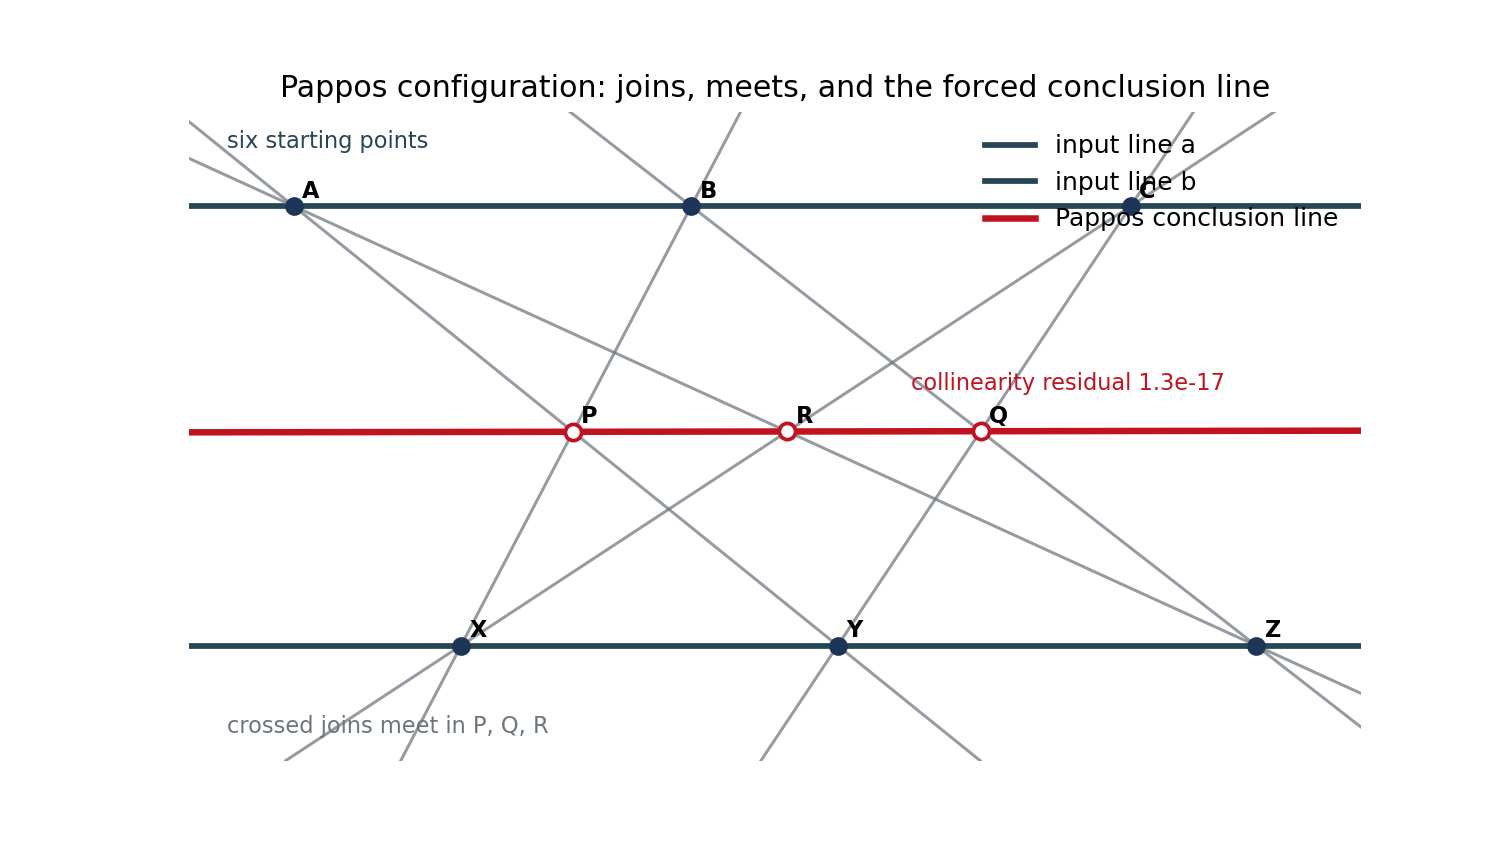

**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/projective-completion-parallel-limit.png**

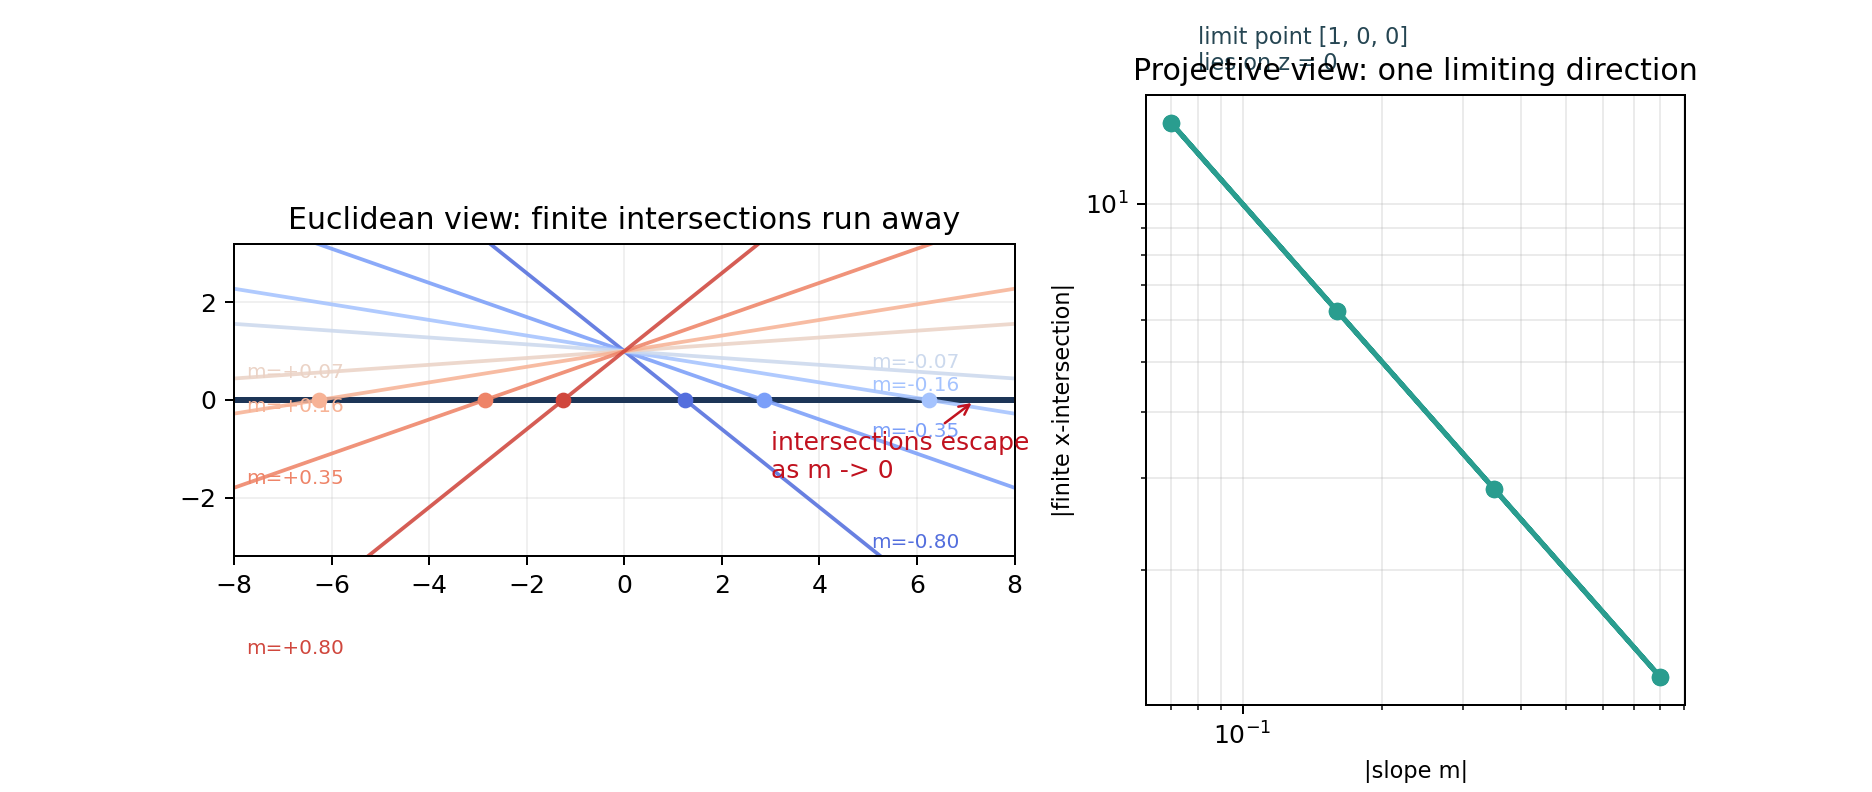

**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/area-cancellation-tiles.png**

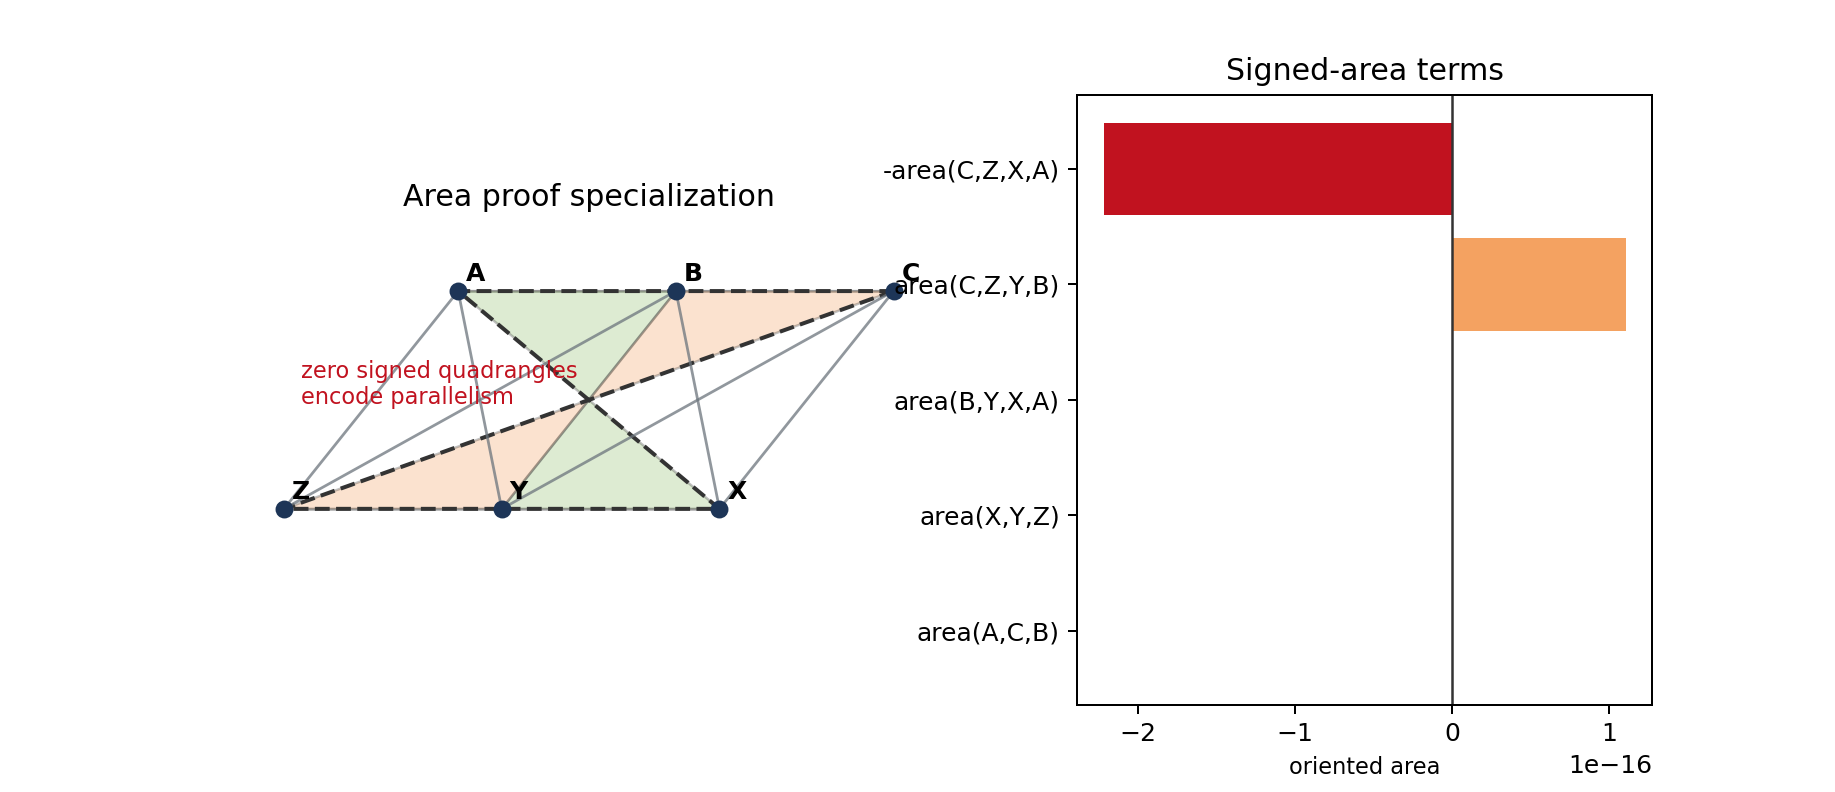

**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/determinant-cross-product-proof.png**

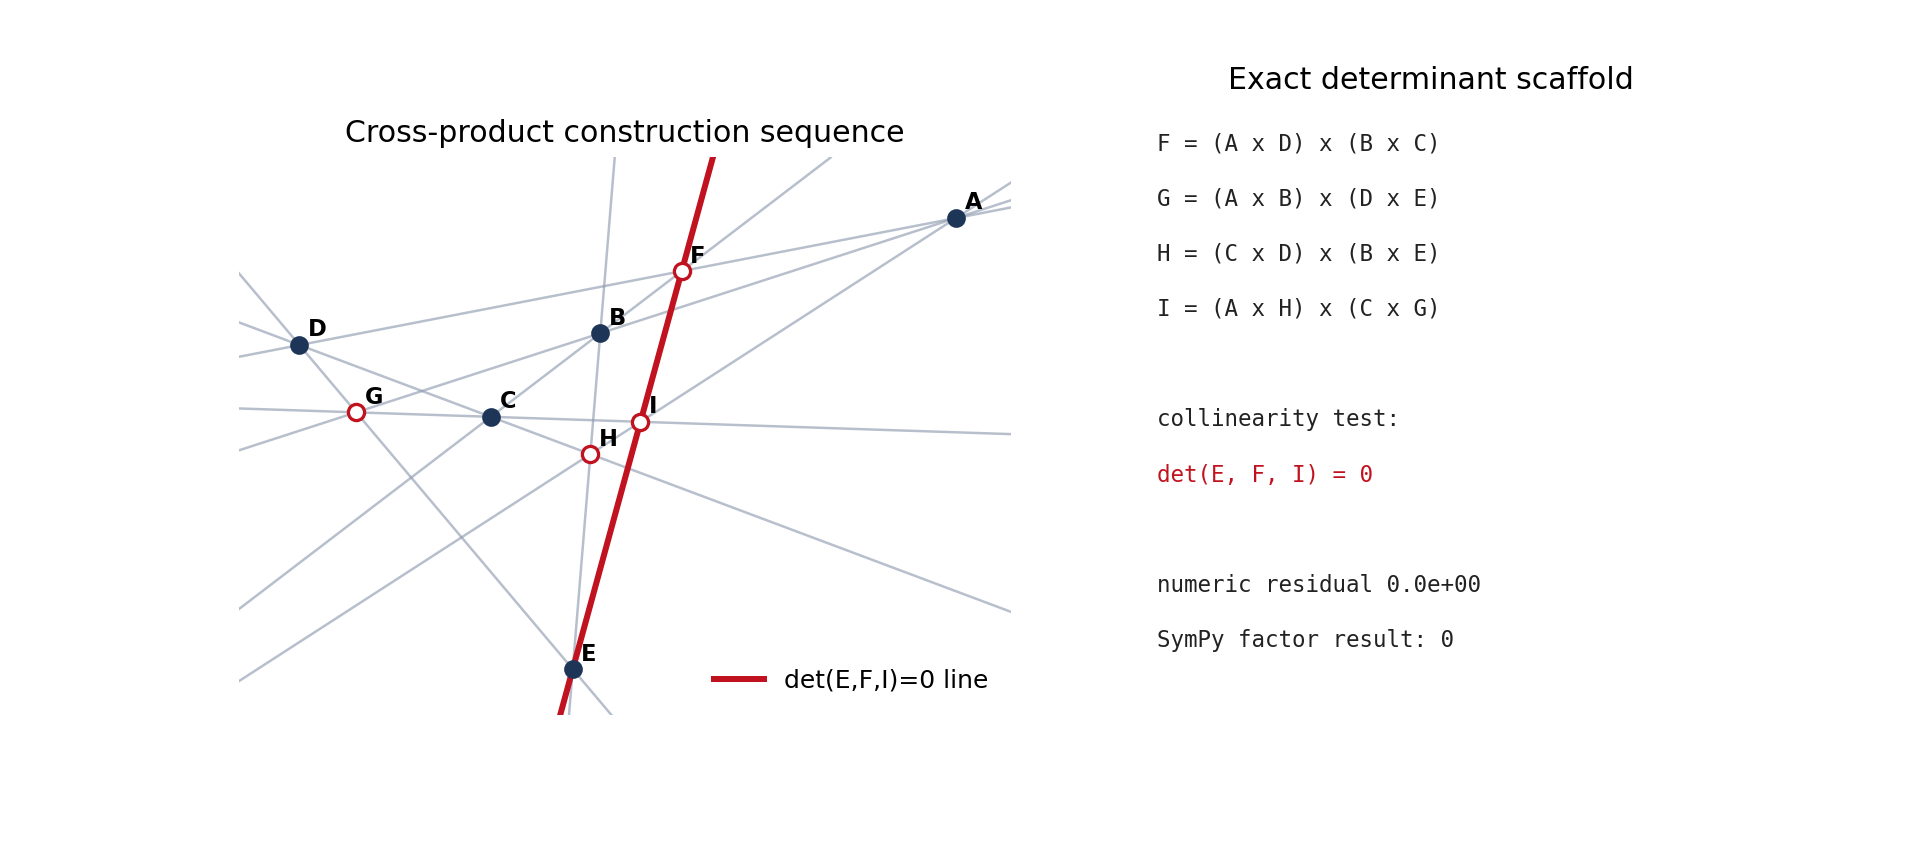

**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pascal-conic-degeneration.png**

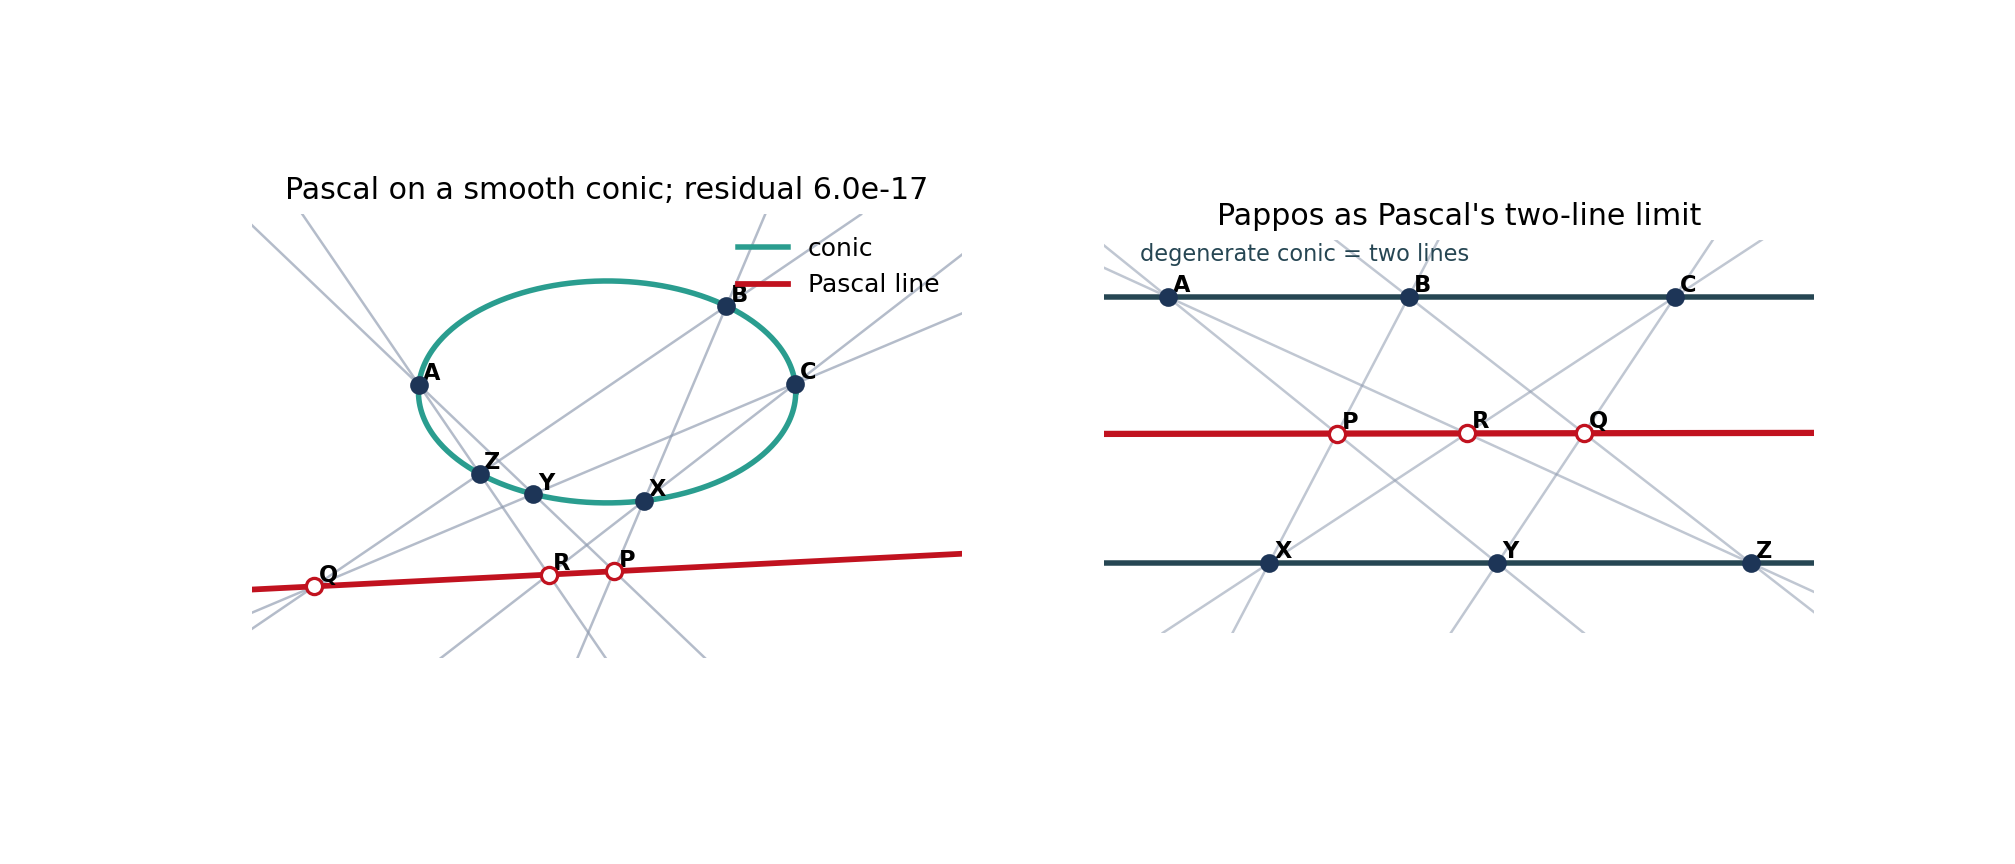

**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/chasles-residual-line-cubic.png**

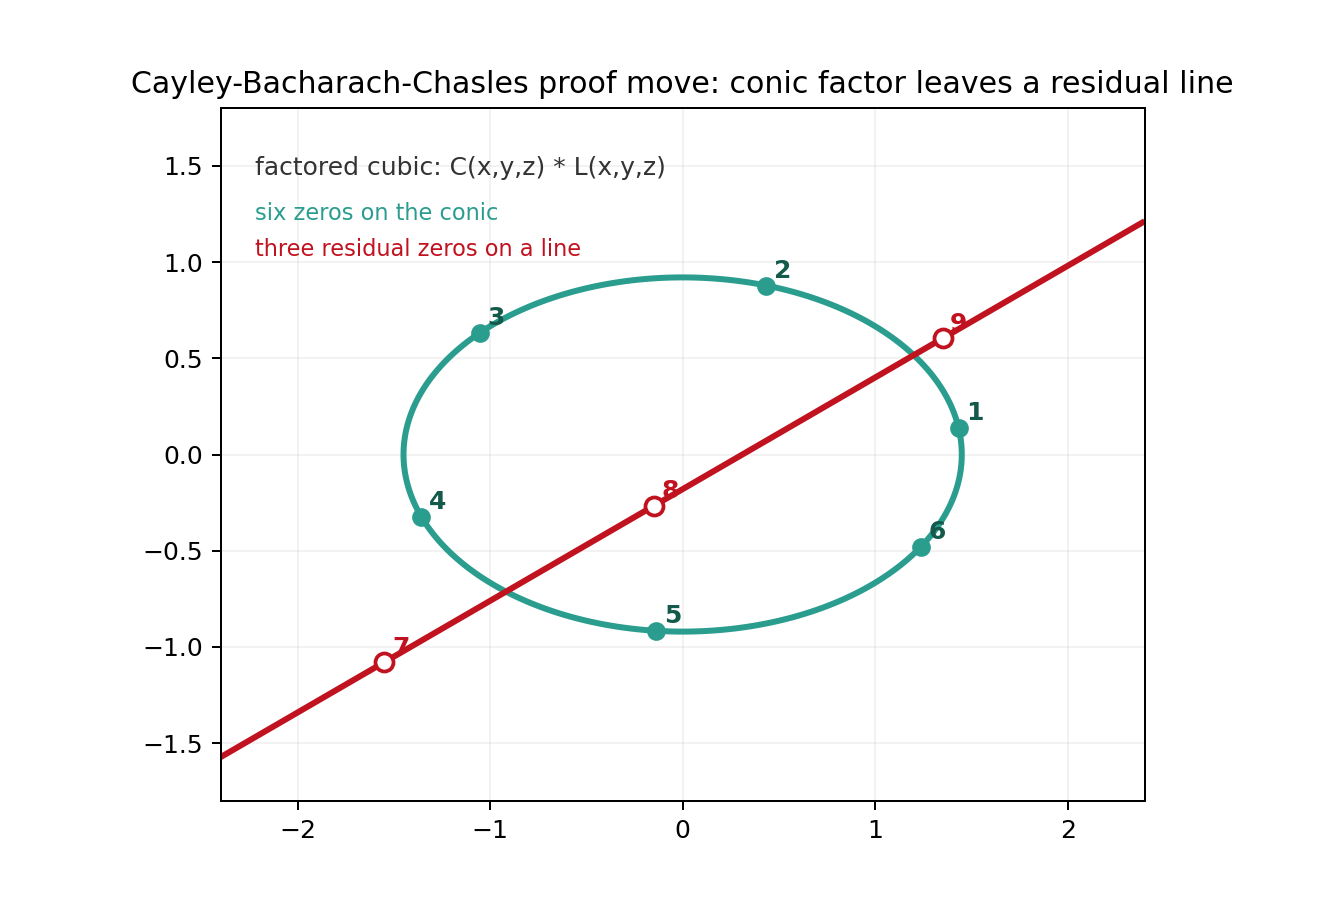

**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/miquel-cross-ratio-circles.png**

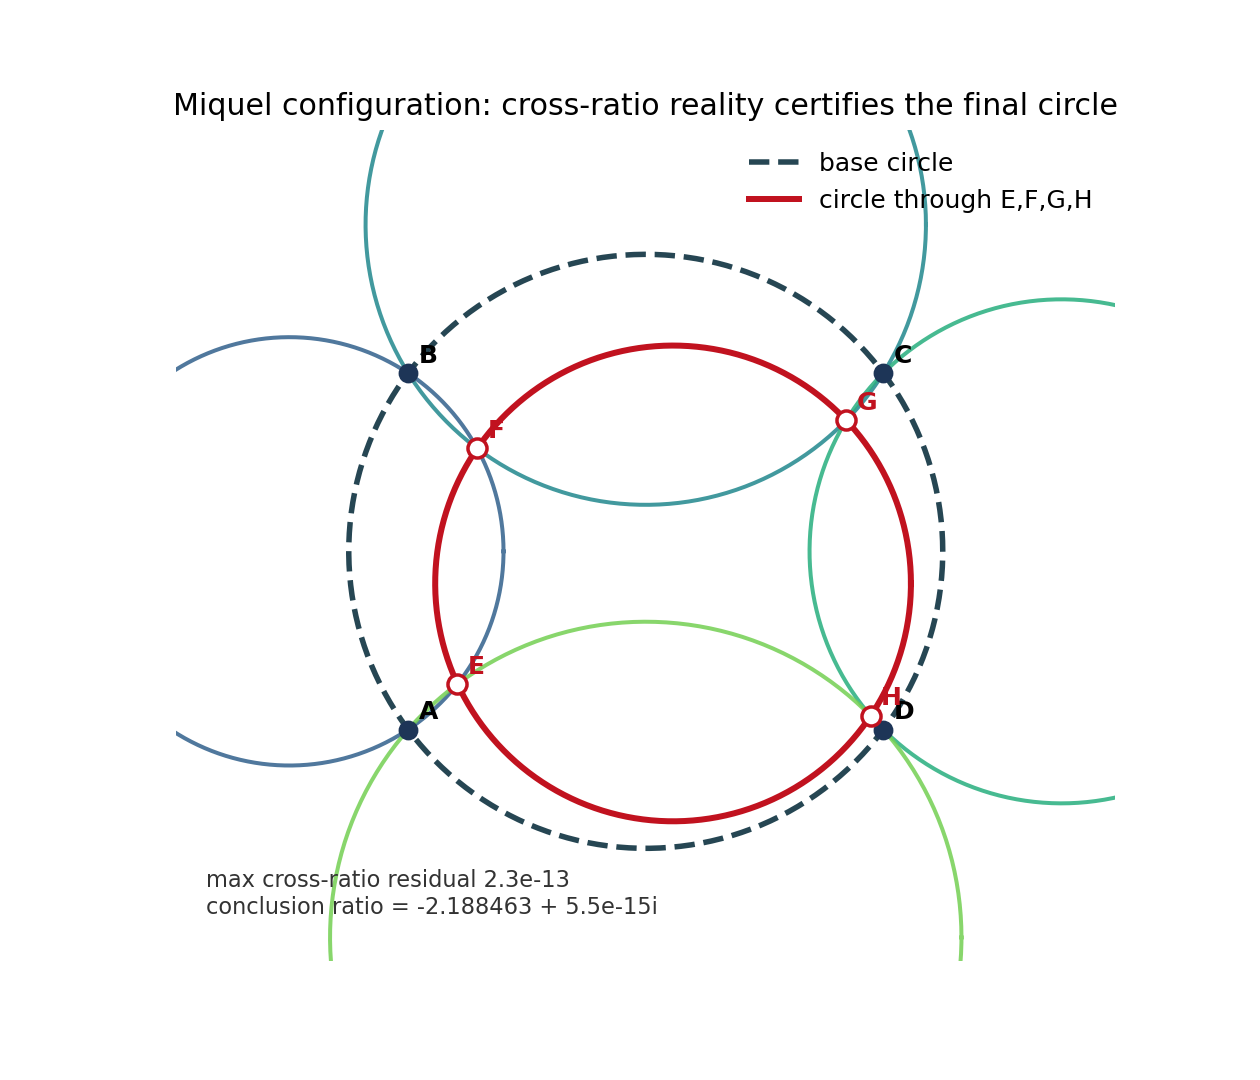

**artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/html/miquel-cross-ratio-lab.html**

In [14]:
for path in artifact_paths:
    display(Markdown(f"**{rel(path)}**"))
    if path.suffix.lower() == ".html":
display_artifact(Path("..") / Path(rel(path)), width="100%", height=560)
    else:
display_artifact(Path("..") / Path(rel(path)), width=780, height=460)


## Applied Lab

Choose one of the proof states and perturb the inputs within the code above.

1. In the Pappos cell, move one starting point along its input line and rerun the cell. The red line should move, but the collinearity residual should remain near zero.
2. In the projective-completion cell, add slopes closer to zero. The finite intersection coordinate should grow like `1 / |m|`, while the limiting homogeneous point remains on `z = 0`.
3. In the Miquel lab, change `BASE_BULGES`. The side circles and second intersections will move, but the cross-ratio imaginary parts should remain tiny unless you choose a degenerate circle intersection.

The habit is the same throughout the chapter: perturb the drawing, recompute the invariant, and distinguish a genuine theorem from a visually plausible coincidence.


## Final Sanity Checks

The final cell records the artifact table, validates artifact size and nonblank raster statistics, and asserts the chapter-specific invariants. These checks are deliberately redundant: if a future edit changes a diagram without updating the algebra, this cell should fail.


In [15]:
observation_table_path = save_table(observation_rows, ARTIFACT_ROOT, "tables", "pappos-observation-targets.csv")
assert observation_table_path.exists() and observation_table_path.stat().st_size > 256
artifact_paths.append(observation_table_path)

assert_artifacts(artifact_paths, min_size=256)
raster_records = []
for path in artifact_paths:
    if path.suffix.lower() == ".png":
        stats = image_stats(path)
        stats["path"] = rel(path)
        assert stats["width"] >= 200 and stats["height"] >= 150
        assert stats["pixel_std"] > 1.0
        raster_records.append(stats)

assert visual_checks["pappos_collinearity_residual"] < 1e-9
assert max(visual_checks["pappos_incidence_residuals"].values()) < 1e-9
assert visual_checks["projective_completion"]["line_at_infinity_incidence_residual"] == 0.0
assert visual_checks["projective_completion"]["max_distance_times_slope_error"] < 1e-12
assert visual_checks["area_identity_residual"] < 1e-9
assert visual_checks["area_final_parallel_residual"] < 1e-9
assert visual_checks["determinant_cross_product"]["symbolic_det_zero"]
assert visual_checks["determinant_cross_product"]["numeric_collinearity_residual"] < 1e-9
assert visual_checks["pascal_collinearity_residual"] < 1e-9
assert visual_checks["chasles_residual_line"]["max_conic_residual_at_six_points"] < 1e-12
assert visual_checks["chasles_residual_line"]["max_line_residual_at_three_points"] < 1e-12
assert visual_checks["miquel_cross_ratio"]["max_cross_ratio_residual"] < 1e-9
assert visual_checks["miquel_cross_ratio"]["circular_point_residual"] < 1e-12
assert all(row["cross_ratio_error"] < 1e-9 for row in visual_checks["miquel_lab_frames"])

visual_checks.update({
    "all_files_exist": all(Path(path).exists() for path in artifact_paths),
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "raster_artifacts": raster_records,
    "observation_table": rel(observation_table_path),
})
save_json(visual_checks, ARTIFACT_ROOT, "checks", "visual-checks.json")

final_sanity = {
    "chapter": 1,
    "notebook_executed": True,
    "source_span": SOURCE_SPAN,
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": {
        "pappos_collinearity_residual": visual_checks["pappos_collinearity_residual"],
        "projective_completion": visual_checks["projective_completion"],
        "area_identity_residual": visual_checks["area_identity_residual"],
        "determinant_cross_product": visual_checks["determinant_cross_product"],
        "pascal_collinearity_residual": visual_checks["pascal_collinearity_residual"],
        "chasles_residual_line": visual_checks["chasles_residual_line"],
        "cross_ratio_error": visual_checks["cross_ratio_error"],
        "all_files_exist": visual_checks["all_files_exist"],
        "raster_count": len(raster_records),
    },
}
save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json")
final_sanity


{'chapter': 1,
 'notebook_executed': True,
 'source_span': 'printed pages 3-32 / PDF pages 25-54; Sections 1.1-1.7',
 'artifacts': ['artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pappos-nine-point-incidence.png',
  'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/projective-completion-parallel-limit.png',
  'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/area-cancellation-tiles.png',
  'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/determinant-cross-product-proof.png',
  'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/pascal-conic-degeneration.png',
  'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/chasles-residual-line-cubic.png',
  'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-variations/figures/miquel-cross-ratio-circles.png',
  'artifacts/chapter-01-pappos-theorem-nine-proofs-and-three-varia

## Takeaways

Pappos's theorem is useful in this opening chapter because it can be seen from many compatible angles without changing its core invariant. As an incidence theorem, it is a statement about joins, meets, and one forced line. As a Euclidean theorem, it explains a parallel conclusion after the projective line at infinity is allowed to participate. As an area proof, it is a signed-polynomial cancellation. As a determinant proof, it is a zero bracket. As a conic theorem, it is Pascal in a degenerate costume and a shadow of Cayley-Bacharach-Chasles. As a circle theorem, it reappears through the reality of cross-ratios in Miquel's configuration.

The computational translation is therefore simple but powerful: do not trust the drawing alone. Represent the objects, compute the incidence relation, and check the invariant that the proof says must survive.
